# Stage 1 pilot: can both routes learn a language-model hybrid?

**Run with Runtime → Run all. Nothing to set.** Reconnect and run all again after a disconnect;
finished runs reload from Drive.

## Why this stage exists

The target experiment is post-training conversion: take a hybrid language model, steer it after
convergence, delete attention, and keep both language modelling and in-context recall while the
KV cache disappears. That is a method rather than a phenomenon, and it is the version of this
work a reviewer can use.

Everything in that experiment depends on one precondition the paper already relies on: **both
routes must be independently able to do the task**. An earlier attempt at a language-model hybrid
failed because neither route learned key–value binding within budget — both sat at 1/L, emitting
some in-context value without learning which. This notebook checks the precondition first, on the
fixed task format, before any steering pipeline is built.

## What it trains

Three models, same budget, same trunk, capacity-matched:

| model | routes | question |
|---|---|---|
| `recurrent_only` | GRU readout | can recurrence carry recall on its own? |
| `retrieval_only` | attention readout | can retrieval carry recall on its own? |
| `hybrid` | both, additive | which route does a free model choose? |

The task is a mixture on every step: **next-token prediction on WikiText-103** plus **in-context
recall** with natural-text filler, at several loads. Language modelling is the behaviour that must
be preserved; recall is the probe whose route can move. Recall pairs occupy one position each
(key embedding + value embedding), the format that made binding learnable in the symbolic model.

## The bar

- **Both routes viable at some load, and the free hybrid retrieval-dominant there:** the
  precondition holds, Stage 2 (four arms + deletion) is worth building at that load, with the
  first non-viable load as the negative control.
- **Only retrieval viable:** widen the GRU (`d_rec`) or lower the loads.
- **Neither viable:** the task or budget is still wrong; the notebook says so rather than
  proceeding.

Reported per load: recall accuracy for each single-route model, and for the free hybrid its
accuracy, D_h, D_c, accuracy with each route deleted, and validation perplexity. Perplexity is
tracked throughout so that a route that solves recall by wrecking the language model is visible.

Send back `LM_PILOT_SUMMARY.txt`.


In [3]:
# Kaggle: no Drive mount, and results go to /kaggle/working so they survive a session restart
# and can be downloaded from the Output tab.
import os
os.environ["LM_PILOT_WORKDIR"] = "/kaggle/working/lm_route_pilot"

In [4]:
import hashlib, json, math, os, pathlib, random, subprocess, sys, time
from dataclasses import dataclass, asdict
from contextlib import nullcontext

PRESET = "full"        # "smoke" = tiny budgets, checks the pipeline only
USE_DRIVE, DRIVE_DIR = False, "/content/drive/MyDrive/lm_route_pilot"

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
if IN_COLAB and USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    WORKDIR = DRIVE_DIR
else:
    WORKDIR = os.environ.get("LM_PILOT_WORKDIR", str(pathlib.Path.cwd() / "lm_route_pilot"))

from importlib.metadata import version, PackageNotFoundError


def _has(pkg):
    try:
        version(pkg); return True
    except PackageNotFoundError:
        return False


for pkg in ("datasets", "transformers"):
    if not _has(pkg):
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib as mpl
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IS_CUDA = DEVICE.type == "cuda"
GPU_NAME = torch.cuda.get_device_name(0) if IS_CUDA else "cpu"
AMP_DTYPE = (torch.bfloat16 if torch.cuda.get_device_capability()[0] >= 8 else torch.float16) if IS_CUDA else torch.bfloat16


def amp():
    return torch.autocast(device_type=DEVICE.type, dtype=AMP_DTYPE, enabled=IS_CUDA)


def sync():
    if IS_CUDA:
        torch.cuda.synchronize()


def P(full, smoke):
    return full if PRESET == "full" else smoke


MODELS = ["recurrent_only", "retrieval_only", "hybrid"]
LOADS = P([2, 4, 8, 16], [2, 4])          # key-value pairs in the recall probe
SEEDS = [0]
STEPS = P(6000, 150)
LOG = P(500, 50)
N_EVAL_REC = P(6, 2)                      # x 32 recall sequences per load
N_EVAL_LM = P(16, 2)                      # x 8 validation windows
TIME_BUDGET_H = P(3.0, 0.2)
CKPT_MINUTES = P(12.0, 2.0)
VIABLE_ACC, DOMINANT = 0.90, 0.70
N_STORIES = P(120_000, 5_000)
SEED0, EVAL_SEED, FORMAT_VERSION = 0, 4321, 1


@dataclass
class Cfg:
    d: int = 512                 # trunk width
    d_rec: int = 512             # GRU hidden size (the storage capacity that sets the boundary)
    n_layers: int = 6            # trunk blocks (transformer, so the trunk is a real sequence model)
    n_heads: int = 8
    mlp_mult: int = 4
    seq_len: int = 512
    lm_batch: int = 8
    rec_batch: int = 8
    lm_weight: float = 1.0
    lr: float = 6e-4
    warmup: int = 200
    weight_decay: float = 0.0
    grad_clip: float = 1.0
    n_keys: int = 256
    n_vals: int = 256
    n_query: int = 4
    filler: int = 64             # natural-text tokens between the facts and the query


CFG = Cfg()
if PRESET == "smoke":
    CFG.warmup, CFG.seq_len = 20, 256

TAG = f"d{CFG.d}_{PRESET}"
WORK = pathlib.Path(WORKDIR).expanduser()
RESDIR, CKPTDIR, FIGDIR, TABDIR = (WORK / f"{n}_{TAG}" for n in ("results", "checkpoints", "figures", "tables"))
for _d in (RESDIR, CKPTDIR, FIGDIR, TABDIR):
    _d.mkdir(parents=True, exist_ok=True)
T_START = time.time()


def set_seed(s):
    torch.manual_seed(s); np.random.seed(s); random.seed(s)


print(f"{GPU_NAME} | {str(AMP_DTYPE).split('.')[-1]} | torch {torch.__version__} | "
      f"loads {LOADS} | {STEPS} steps per run | {len(MODELS) * len(LOADS) * len(SEEDS)} runs")
print(f"work dir {WORK}")


Tesla T4 | float16 | torch 2.10.0+cu128 | loads [2, 4, 8, 16] | 6000 steps per run | 12 runs
work dir /kaggle/working/lm_route_pilot


In [5]:
def keyof(spec):
    return hashlib.md5(json.dumps(spec, sort_keys=True, default=str).encode()).hexdigest()[:16]


class Records:
    def __init__(self, path):
        self.path, self.recs = path, {}
        if path.exists():
            for line in path.read_text().splitlines():
                try:
                    r = json.loads(line); self.recs[r["_key"]] = r
                except (json.JSONDecodeError, KeyError):
                    pass

    def get(self, spec):
        return self.recs.get(keyof(spec))

    def put(self, spec, payload):
        r = {"_key": keyof(spec), "_spec": spec, "_t": time.time(), **payload}
        self.recs[r["_key"]] = r
        with open(self.path, "a") as f:
            f.write(json.dumps(r, default=float) + "\n"); f.flush(); os.fsync(f.fileno())
        return r

    def frame(self):
        return pd.DataFrame([{**r["_spec"], **{k: v for k, v in r.items()
                                               if not k.startswith("_") and k != "trace"}}
                             for r in self.recs.values()])


def ckpt_save(name, obj):
    p = CKPTDIR / f"{name}.pt"
    torch.save(obj, p.with_suffix(".tmp")); os.replace(p.with_suffix(".tmp"), p)


def ckpt_load(name):
    p = CKPTDIR / f"{name}.pt"
    if p.exists():
        try:
            return torch.load(p, map_location=DEVICE, weights_only=False)
        except Exception as e:
            print(f"  checkpoint unreadable ({type(e).__name__})")
    return None


def ckpt_delete(name):
    for suf in (".pt", ".tmp"):
        (CKPTDIR / f"{name}{suf}").unlink(missing_ok=True)


REC = Records(RESDIR / "records.jsonl")
print(f"{len(REC.recs)} finished run(s) on disk")


0 finished run(s) on disk


In [6]:
# Text: WikiText-103 tokenised once with the GPT-2 tokenizer, remapped to the most frequent
# LM_VOCAB tokens so the embedding and softmax stay small. Recall uses reserved symbols appended
# after the text vocabulary, so the two objectives share one output layer.
from transformers import AutoTokenizer

LM_VOCAB = 8000
DATADIR = WORK / "data"
DATADIR.mkdir(parents=True, exist_ok=True)


def prepare_text():
    stem = f"wikitext103_{N_STORIES}_v{LM_VOCAB}"
    ftr, fva, fmeta = (DATADIR / f"{stem}_{s}" for s in ("train.npy", "val.npy", "meta.json"))
    if ftr.exists() and fva.exists() and fmeta.exists():
        return np.load(ftr, mmap_mode="r"), np.load(fva, mmap_mode="r"), json.loads(fmeta.read_text())
    from datasets import load_dataset
    tok = AutoTokenizer.from_pretrained("gpt2")
    try:
        ds = load_dataset("Salesforce/wikitext", "wikitext-103-raw-v1")
    except Exception:
        ds = load_dataset("wikitext", "wikitext-103-raw-v1")

    def enc(split, limit=None):
        txt = [t for t in ds[split]["text"] if len(t.strip()) > 40]
        if limit:
            txt = txt[:limit]
        out, t0 = [], time.time()
        for i in range(0, len(txt), 2000):
            out.append(np.asarray(sum(tok(txt[i:i + 2000], add_special_tokens=False)["input_ids"], []),
                                  dtype=np.int32))
            if (i // 2000) % 20 == 0 and i:
                print(f"  {split}: {i:,} paragraphs, {(time.time() - t0) / 60:.1f} min", flush=True)
        return np.concatenate(out)

    raw_tr, raw_va = enc("train", N_STORIES), enc("validation")
    counts = np.bincount(raw_tr.astype(np.int64), minlength=len(tok))
    keep = np.argsort(-counts, kind="stable")[: LM_VOCAB - 1]
    lut = np.zeros(len(tok), dtype=np.uint16)
    lut[keep] = np.arange(1, LM_VOCAB, dtype=np.uint16)
    np.save(ftr, lut[raw_tr]); np.save(fva, lut[raw_va])
    meta = {"train_tokens": int(len(raw_tr)), "val_tokens": int(len(raw_va)),
            "coverage": float(counts[keep].sum() / counts.sum())}
    fmeta.write_text(json.dumps(meta))
    return np.load(ftr, mmap_mode="r"), np.load(fva, mmap_mode="r"), meta


TRAIN, VAL, META = prepare_text()
UNK = 0
SEP, QRY = LM_VOCAB, LM_VOCAB + 1
KEY0 = LM_VOCAB + 2
VAL0 = KEY0 + CFG.n_keys
VOCAB = VAL0 + CFG.n_vals
IGNORE = -100
CHANCE = 1.0 / CFG.n_vals
print(f"text: {META['train_tokens']:,} train tokens, {META['val_tokens']:,} val; "
      f"top-{LM_VOCAB - 1} covers {100 * META['coverage']:.2f}% | full vocab {VOCAB}")


def lm_batch(B, data, rng):
    T = CFG.seq_len
    ix = rng.integers(0, len(data) - T - 1, size=B)
    arr = np.stack([np.asarray(data[i:i + T + 1], dtype=np.int64) for i in ix])
    t = torch.from_numpy(arr).to(DEVICE, non_blocking=True)
    return t[:, :-1].contiguous(), t[:, 1:].contiguous()


def recall_batch(B, load, gen, data, rng):
    # facts (one position each: key + value embedding), natural-text filler, then queries
    dev = gen.device
    nq = min(CFG.n_query, load)
    T = 1 + load + CFG.filler + 1 + 2 * nq
    keys = torch.rand(B, CFG.n_keys, generator=gen, device=dev).argsort(-1)[:, :load]
    vals = torch.randint(0, CFG.n_vals, (B, load), generator=gen, device=dev)
    qidx = torch.rand(B, load, generator=gen, device=dev).argsort(-1)[:, :nq]
    x_key = torch.full((B, T), UNK, dtype=torch.long, device=dev)
    x_val = torch.full((B, T), UNK, dtype=torch.long, device=dev)
    y = torch.full((B, T), IGNORE, dtype=torch.long, device=dev)
    x_key[:, 0] = SEP
    x_key[:, 1:1 + load] = KEY0 + keys
    x_val[:, 1:1 + load] = VAL0 + vals
    p = 1 + load
    ix = rng.integers(0, len(data) - CFG.filler - 1, size=B)
    filler = torch.from_numpy(np.stack([np.asarray(data[i:i + CFG.filler], dtype=np.int64) for i in ix]))
    x_key[:, p:p + CFG.filler] = filler.to(dev)
    p += CFG.filler
    x_key[:, p] = SEP
    qpos = p + 1 + 2 * torch.arange(nq, device=dev)
    x_key[:, qpos] = QRY
    x_key[:, qpos + 1] = KEY0 + keys.gather(1, qidx)
    y[:, qpos + 1] = VAL0 + vals.gather(1, qidx)
    return (x_key.to(DEVICE, non_blocking=True), x_val.to(DEVICE, non_blocking=True),
            y.to(DEVICE, non_blocking=True))


_g = torch.Generator(device="cpu"); _g.manual_seed(0)
_rng = np.random.default_rng(0)
_k, _v, _y = recall_batch(1, 3, _g, VAL, _rng)
_n = 1 + 3 + 8
print("\nrecall example (3 pairs, first tokens then the tail):")
print("  facts:", " ".join(f"k{int(a) - KEY0}+v{int(b) - VAL0}" if b >= VAL0 else "|"
                           for a, b in zip(_k[0, :_n].cpu(), _v[0, :_n].cpu())))
print("  tail :", " ".join("?" if int(t) == QRY else ("|" if int(t) == SEP else
                                                     (f"Qk{int(t) - KEY0}" if t >= KEY0 else "w"))
                           for t in _k[0, -9:].cpu()))
print("  targets:", [(i, f"v{int(t) - VAL0}") for i, t in enumerate(_y[0]) if t != IGNORE])


def eval_sets(load):
    g = torch.Generator(device="cpu"); g.manual_seed(EVAL_SEED + load)
    rng = np.random.default_rng(EVAL_SEED + load)
    rec = [recall_batch(32, load, g, VAL, rng) for _ in range(N_EVAL_REC)]
    rng2 = np.random.default_rng(EVAL_SEED)
    lm = [lm_batch(8, VAL, rng2) for _ in range(N_EVAL_LM)]
    return rec, lm


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

wikitext-103-raw-v1/validation-00000-of-(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/1801350 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

  train: 40,000 paragraphs, 0.5 min
  train: 80,000 paragraphs, 1.1 min
text: 16,609,161 train tokens, 240,987 val; top-7999 covers 88.77% | full vocab 8514

recall example (3 pairs, first tokens then the tail):
  facts: | k83+v13 k94+v71 k245+v184 | | | | | | | |
  tail : w w | ? Qk83 ? Qk94 ? Qk245
  targets: [(70, 'v13'), (72, 'v71'), (74, 'v184')]


In [7]:
# The paper's dual-route readout on top of a transformer trunk. The trunk is a real sequence model,
# so both routes read contextual states; the routes meet only as a sum of logits, which keeps each
# one independently priceable, ablatable and resamplable.
class RMSNorm(nn.Module):
    def __init__(self, d, eps=1e-6):
        super().__init__()
        self.w, self.eps = nn.Parameter(torch.ones(d)), eps

    def forward(self, x):
        return self.w * x * torch.rsqrt(x.float().pow(2).mean(-1, keepdim=True) + self.eps).to(x.dtype)


def rope(T, dh, device, base=10000.0):
    inv = 1.0 / (base ** (torch.arange(0, dh, 2, device=device).float() / dh))
    f = torch.outer(torch.arange(T, device=device).float(), inv)
    return f.cos(), f.sin()


def apply_rope(x, cos, sin):
    x1, x2 = x[..., ::2], x[..., 1::2]
    cos, sin = cos[None, None].to(x.dtype), sin[None, None].to(x.dtype)
    return torch.stack([x1 * cos - x2 * sin, x1 * sin + x2 * cos], -1).flatten(-2)


class Block(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.h, self.dh = cfg.n_heads, cfg.d // cfg.n_heads
        self.n1, self.n2 = RMSNorm(cfg.d), RMSNorm(cfg.d)
        self.qkv = nn.Linear(cfg.d, 3 * cfg.d, bias=False)
        self.o = nn.Linear(cfg.d, cfg.d, bias=False)
        self.mlp = nn.Sequential(nn.Linear(cfg.d, cfg.mlp_mult * cfg.d, bias=False), nn.GELU(),
                                 nn.Linear(cfg.mlp_mult * cfg.d, cfg.d, bias=False))

    def forward(self, x, cos, sin):
        B, T, D = x.shape
        q, k, v = self.qkv(self.n1(x)).view(B, T, 3, self.h, self.dh).permute(2, 0, 3, 1, 4)
        q, k = apply_rope(q, cos, sin), apply_rope(k, cos, sin)
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        x = x + self.o(y.transpose(1, 2).reshape(B, T, D))
        return x + self.mlp(self.n2(x))


class DualRouteLM(nn.Module):
    def __init__(self, cfg, recurrent=True, retrieval=True):
        super().__init__()
        self.cfg, self.recurrent, self.retrieval = cfg, recurrent, retrieval
        self.emb_key = nn.Embedding(VOCAB, cfg.d)
        self.emb_val = nn.Embedding(VOCAB, cfg.d)
        self.blocks = nn.ModuleList([Block(cfg) for _ in range(cfg.n_layers)])
        self.norm = RMSNorm(cfg.d)
        self.lm_head = nn.Linear(cfg.d, VOCAB, bias=False)     # next-token prediction, always on
        if recurrent:
            self.gru = nn.GRU(cfg.d, cfg.d_rec, batch_first=True)
            self.proj_h = nn.Linear(cfg.d_rec, cfg.d_rec)
            self.w_h = nn.Linear(cfg.d_rec, VOCAB, bias=False)
        if retrieval:
            self.q = nn.Linear(cfg.d_rec if recurrent else cfg.d, cfg.d, bias=False)
            self.k = nn.Linear(cfg.d_rec if recurrent else cfg.d, cfg.d, bias=False)
            self.v = nn.Linear(cfg.d_rec if recurrent else cfg.d, cfg.d, bias=False)
            self.proj_c = nn.Linear(cfg.d, cfg.d)
            self.w_c = nn.Linear(cfg.d, VOCAB, bias=False)
        for m in self.modules():
            if isinstance(m, (nn.Linear, nn.Embedding)):
                nn.init.normal_(m.weight, std=0.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.zeros_(m.bias)

    def trunk(self, x_key, x_val):
        h = self.emb_key(x_key) + self.emb_val(x_val)
        cos, sin = rope(h.shape[1], self.cfg.d // self.cfg.n_heads, h.device)
        for blk in self.blocks:
            h = blk(h, cos, sin)
        return self.norm(h)

    def lm_logits(self, x_key, x_val):
        return self.lm_head(self.trunk(x_key, x_val))

    def routes(self, S, qpos):
        B, T, _ = S.shape
        G = self.gru(S)[0] if self.recurrent else S
        idx = qpos[None, :, None].expand(B, -1, G.shape[-1])
        h_rec = G.gather(1, idx) if self.recurrent else None
        c = None
        if self.retrieval:
            q = self.q(G.gather(1, idx))
            k, v = self.k(G), self.v(G)
            pos = torch.arange(T, device=S.device)
            allowed = pos[None, :] < qpos[:, None]          # strictly earlier: no self-leak
            mask = torch.zeros(len(qpos), T, device=S.device).masked_fill(~allowed, float("-inf"))
            c = F.scaled_dot_product_attention(q.unsqueeze(1), k.unsqueeze(1), v.unsqueeze(1),
                                               attn_mask=mask[None, None]).squeeze(1)
        return h_rec, c

    def recall_logits(self, x_key, x_val, qpos, drop=None, perm=None):
        h_rec, c = self.routes(self.trunk(x_key, x_val), qpos)
        ref = h_rec if h_rec is not None else c
        if drop == "recurrent":
            h_rec = None
        elif perm is not None and perm[0] == "recurrent" and h_rec is not None:
            h_rec = h_rec[perm[1]]
        if drop == "retrieval":
            c = None
        elif perm is not None and perm[0] == "retrieval" and c is not None:
            c = c[perm[1]]
        lh = self.w_h(F.gelu(self.proj_h(h_rec))) if (self.recurrent and h_rec is not None) else None
        lc = self.w_c(F.gelu(self.proj_c(c))) if (self.retrieval and c is not None) else None
        if lh is None and lc is None:
            return torch.zeros(ref.shape[0], ref.shape[1], VOCAB, device=ref.device), None, None
        out = lh if lc is None else (lc if lh is None else lh + lc)
        return out, lh, lc


def build(kind, seed):
    set_seed(seed)
    return DualRouteLM(CFG, recurrent=kind != "retrieval_only", retrieval=kind != "recurrent_only").to(DEVICE)


for _k in MODELS:
    _m = build(_k, 0)
    _n = sum(p.numel() for p in _m.parameters())
    _e = _m.emb_key.weight.numel() + _m.emb_val.weight.numel() + _m.lm_head.weight.numel()
    print(f"{_k:<16}{_n / 1e6:6.2f}M parameters ({(_n - _e) / 1e6:5.2f}M excluding embeddings and LM head)")
del _m


recurrent_only   38.16M parameters (25.08M excluding embeddings and LM head)
retrieval_only   37.37M parameters (24.29M excluding embeddings and LM head)
hybrid           43.56M parameters (30.49M excluding embeddings and LM head)


In [8]:
def qpos_of(y):
    return (y[0] != IGNORE).nonzero(as_tuple=True)[0]


@torch.no_grad()
def evaluate(model, rec_batches, lm_batches):
    was = model.training
    model.eval()
    tot = dict.fromkeys(["clean", "rec_res", "ret_res", "no_rec", "no_ret"], 0.0)
    n = 0
    for x_key, x_val, y in rec_batches:
        qpos = qpos_of(y)
        tgt = y[:, qpos]
        perm = torch.roll(torch.arange(x_key.shape[0], device=DEVICE), 1)

        def hit(**kw):
            with amp():
                lg = model.recall_logits(x_key, x_val, qpos, **kw)[0]
            return float((lg.argmax(-1) == tgt).sum())

        tot["clean"] += hit()
        if model.recurrent:
            tot["rec_res"] += hit(perm=("recurrent", perm)); tot["no_rec"] += hit(drop="recurrent")
        if model.retrieval:
            tot["ret_res"] += hit(perm=("retrieval", perm)); tot["no_ret"] += hit(drop="retrieval")
        n += tgt.numel()
    m = {k: v / n for k, v in tot.items()}
    acc = m["clean"]
    head = max(acc - CHANCE, 1e-9)
    nll, ntok = 0.0, 0
    for x, y in lm_batches:
        with amp():
            lg = model.lm_logits(x, torch.zeros_like(x))
        nll += float(F.cross_entropy(lg.float().reshape(-1, VOCAB), y.reshape(-1), reduction="sum"))
        ntok += y.numel()
    out = {"acc": acc, "ppl": math.exp(nll / ntok),
           "D_rec": float(np.clip((acc - m["rec_res"]) / head, 0, 1)) if model.recurrent else float("nan"),
           "D_ret": float(np.clip((acc - m["ret_res"]) / head, 0, 1)) if model.retrieval else float("nan"),
           "acc_no_rec": m["no_rec"] if model.recurrent else acc,
           "acc_no_ret": m["no_ret"] if model.retrieval else acc}
    if was:
        model.train()
    return out


def train_run(key, kind, load, seed):
    model = build(kind, seed)
    opt = torch.optim.AdamW(model.parameters(), lr=CFG.lr, betas=(0.9, 0.95),
                            weight_decay=CFG.weight_decay)
    scaler = torch.amp.GradScaler("cuda", enabled=IS_CUDA and AMP_DTYPE == torch.float16)
    rec_b, lm_b = eval_sets(load)
    start, trace, rt, rs = 0, [], 0.0, 0
    ck = ckpt_load(f"run_{key}")
    if ck is not None:
        model.load_state_dict(ck["model"]); opt.load_state_dict(ck["opt"])
        if ck["scaler"]:
            scaler.load_state_dict(ck["scaler"])
        start, trace, rt, rs = ck["step"], ck["trace"], ck["rt"], ck["rs"]
        print(f"    resumed at step {start}/{STEPS}")
    rng = np.random.default_rng([seed, int(key[:8], 16), start])
    gen = torch.Generator(device=DEVICE); gen.manual_seed(int(rng.integers(2 ** 62)))
    model.train()
    last_ck, lm_l, rc_l = time.time(), [], []
    for step in range(start + 1, STEPS + 1):
        sync(); t0 = time.time()
        for g in opt.param_groups:
            g["lr"] = CFG.lr * min(1.0, step / CFG.warmup)
        opt.zero_grad(set_to_none=True)
        x, y = lm_batch(CFG.lm_batch, TRAIN, rng)              # next-token prediction
        with amp():
            lg = model.lm_logits(x, torch.zeros_like(x))
        loss_lm = F.cross_entropy(lg.float().reshape(-1, VOCAB), y.reshape(-1))
        scaler.scale(CFG.lm_weight * loss_lm).backward()
        x_key, x_val, yr = recall_batch(CFG.rec_batch, load, gen, TRAIN, rng)   # recall probe
        qpos = qpos_of(yr)
        with amp():
            out = model.recall_logits(x_key, x_val, qpos)[0]
        loss_rc = F.cross_entropy(out.float().reshape(-1, VOCAB), yr[:, qpos].reshape(-1))
        scaler.scale(loss_rc).backward()
        scaler.unscale_(opt)
        nn.utils.clip_grad_norm_(model.parameters(), CFG.grad_clip)
        scaler.step(opt); scaler.update()
        sync(); rt += time.time() - t0; rs += 1
        lm_l.append(float(loss_lm.detach())); rc_l.append(float(loss_rc.detach()))
        if step == start + 20:
            print(f"    {1000 * rt / rs:.0f} ms/step, about {rt / rs * (STEPS - step) / 60:.0f} min left",
                  flush=True)
        if step % LOG == 0 or step == STEPS:
            ev = evaluate(model, rec_b, lm_b)
            trace.append({"step": step, "lm_loss": float(np.mean(lm_l)), "rc_loss": float(np.mean(rc_l)), **ev})
            print(f"    step {step:>5}  lm {np.mean(lm_l):.3f} (ppl {ev['ppl']:.1f})  "
                  f"recall {np.mean(rc_l):.3f}  acc {ev['acc']:.3f}"
                  + (f"  D_rec {ev['D_rec']:.2f} D_ret {ev['D_ret']:.2f}" if kind == "hybrid" else ""),
                  flush=True)
            lm_l, rc_l = [], []
        if step < STEPS and time.time() - last_ck > 60 * CKPT_MINUTES:
            ckpt_save(f"run_{key}", {"model": model.state_dict(), "opt": opt.state_dict(),
                                     "scaler": scaler.state_dict(), "step": step, "trace": trace,
                                     "rt": rt, "rs": rs})
            last_ck = time.time()
    out = {**evaluate(model, rec_b, lm_b), "trace": trace, "ms_per_step": 1000 * rt / max(rs, 1),
           "params": sum(p.numel() for p in model.parameters())}
    ckpt_delete(f"run_{key}")
    del model, opt
    if IS_CUDA:
        torch.cuda.empty_cache()
    return out


In [9]:
# Timing probe, then the runs. Loads run smallest first and the notebook stops adding loads once
# the budget is spent, so a partial result is still a usable boundary.
_m = build("hybrid", 0)
_opt = torch.optim.AdamW(_m.parameters(), lr=CFG.lr)
_rng = np.random.default_rng(0)
_gen = torch.Generator(device=DEVICE); _gen.manual_seed(0)
for _ in range(3):
    _x, _y = lm_batch(CFG.lm_batch, TRAIN, _rng)
    with amp():
        _l = _m.lm_logits(_x, torch.zeros_like(_x))
    F.cross_entropy(_l.float().reshape(-1, VOCAB), _y.reshape(-1)).backward()
    _opt.zero_grad(set_to_none=True)
sync(); _t0 = time.time()
_x, _y = lm_batch(CFG.lm_batch, TRAIN, _rng)
with amp():
    _l = _m.lm_logits(_x, torch.zeros_like(_x))
F.cross_entropy(_l.float().reshape(-1, VOCAB), _y.reshape(-1)).backward()
_xk, _xv, _yr = recall_batch(CFG.rec_batch, max(LOADS), _gen, TRAIN, _rng)
_qp = qpos_of(_yr)
with amp():
    _o = _m.recall_logits(_xk, _xv, _qp)[0]
F.cross_entropy(_o.float().reshape(-1, VOCAB), _yr[:, _qp].reshape(-1)).backward()
sync()
MS = 1000 * (time.time() - _t0)
del _m, _opt, _l, _o
if IS_CUDA:
    torch.cuda.empty_cache()
_per = MS * STEPS / 60000
print(f"about {MS:.0f} ms/step -> {_per:.0f} min per run, "
      f"{_per * len(MODELS) * len(LOADS) * len(SEEDS) / 60:.1f} h for all runs (budget {TIME_BUDGET_H} h)\n")

print(f"{'model':<16}{'load':>5}{'acc':>7}{'ppl':>8}{'noRec':>7}{'noRet':>7}{'D_rec':>7}{'D_ret':>7}{'min':>6}")
for load in LOADS:
    if (time.time() - T_START) / 3600 > TIME_BUDGET_H:
        print(f"time budget reached; stopping before load {load}")
        break
    for kind in MODELS:
        for seed in SEEDS:
            spec = {"block": "run", "kind": kind, "load": load, "seed": seed, "steps": STEPS,
                    "cfg": asdict(CFG), "lm_vocab": LM_VOCAB, "format": FORMAT_VERSION}
            r = REC.get(spec)
            if r is None:
                print(f"  [{kind} load {load} seed {seed}]", flush=True)
                r = REC.put(spec, train_run(keyof(spec), kind, load, seed))
            print(f"{kind:<16}{load:>5}{r['acc']:>7.3f}{r['ppl']:>8.1f}{r['acc_no_rec']:>7.3f}"
                  f"{r['acc_no_ret']:>7.3f}{r['D_rec']:>7.2f}{r['D_ret']:>7.2f}"
                  f"{r.get('ms_per_step', float('nan')) * STEPS / 60000:>6.0f}", flush=True)


about 325 ms/step -> 33 min per run, 6.5 h for all runs (budget 3.0 h)

model            load    acc     ppl  noRec  noRet  D_rec  D_ret   min
  [recurrent_only load 2 seed 0]
    109 ms/step, about 11 min left
    step   500  lm 5.776 (ppl 163.3)  recall 6.125  acc 0.003
    step  1000  lm 4.993 (ppl 137.2)  recall 5.328  acc 0.036
    step  1500  lm 4.875 (ppl 125.1)  recall 4.108  acc 0.193
    step  2000  lm 4.758 (ppl 110.9)  recall 1.831  acc 0.734
    step  2500  lm 4.657 (ppl 104.9)  recall 0.662  acc 0.932
    step  3000  lm 4.593 (ppl 99.9)  recall 0.403  acc 0.951
    step  3500  lm 4.535 (ppl 91.8)  recall 0.213  acc 0.979
    step  4000  lm 4.439 (ppl 82.2)  recall 0.151  acc 0.995
    step  4500  lm 4.345 (ppl 76.7)  recall 0.170  acc 0.990
    step  5000  lm 4.267 (ppl 71.5)  recall 0.113  acc 0.990
    step  5500  lm 4.196 (ppl 66.3)  recall 0.144  acc 0.995
    step  6000  lm 4.124 (ppl 62.4)  recall 0.121  acc 0.995
recurrent_only      2  0.995    62.4  0.000  0.995  

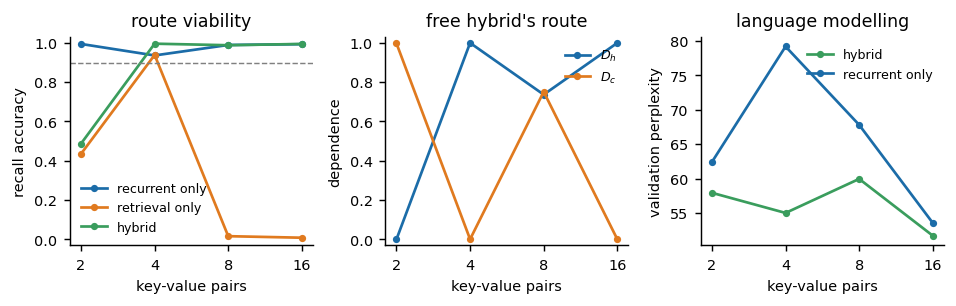

=== LANGUAGE-MODEL ROUTE PILOT | 2026-09-14 01:55 ===
Tesla T4 | float16 | trunk d=512, 6 layers, GRU 512 | seq 512, filler 64 | 6000 steps | LM + recall mixture | 2.3 h elapsed

per load (accuracy of each single-route model, then the free hybrid):
      recurrent_only  retrieval_only  hybrid  hybrid_ppl  D_rec  D_ret  acc_no_rec  acc_no_ret  rec_only_ppl  rec_viable  ret_viable  ret_dominant  candidate
load                                                                                                                                                         
2              0.995           0.435   0.487      57.929  0.000  0.997       0.487       0.008        62.409        True       False          True       True
4              0.936           0.939   0.996      55.005  1.000  0.000       0.001       0.996        79.181        True        True         False      False
8              0.990           0.016   0.988      59.949  0.737  0.751       0.001       0.517        67.797        Tru

In [10]:
R = REC.frame()
R = R[(R["steps"] == STEPS) & (R["format"] == FORMAT_VERSION)] if len(R) else R
lines = [f"=== LANGUAGE-MODEL ROUTE PILOT | {time.strftime('%Y-%m-%d %H:%M')} ===",
         f"{GPU_NAME} | {str(AMP_DTYPE).split('.')[-1]} | trunk d={CFG.d}, {CFG.n_layers} layers, "
         f"GRU {CFG.d_rec} | seq {CFG.seq_len}, filler {CFG.filler} | {STEPS} steps | "
         f"LM + recall mixture | {(time.time() - T_START) / 3600:.1f} h elapsed"]

if not len(R):
    lines.append("no runs finished")
    VERDICT = "NO RUNS"
else:
    piv = R.pivot_table(index="load", columns="kind", values="acc", aggfunc="mean")
    for c in MODELS:
        if c not in piv:
            piv[c] = np.nan
    hyb = R[R.kind == "hybrid"].groupby("load").agg(
        hybrid_ppl=("ppl", "mean"), D_rec=("D_rec", "mean"), D_ret=("D_ret", "mean"),
        acc_no_rec=("acc_no_rec", "mean"), acc_no_ret=("acc_no_ret", "mean"))
    lmppl = R[R.kind == "recurrent_only"].groupby("load").ppl.mean().rename("rec_only_ppl")
    T = piv[MODELS].join(hyb).join(lmppl)
    T["rec_viable"] = T["recurrent_only"] >= VIABLE_ACC
    T["ret_viable"] = T["retrieval_only"] >= VIABLE_ACC
    T["ret_dominant"] = T.D_ret >= DOMINANT
    T["candidate"] = T.rec_viable & T.ret_dominant
    T.to_csv(TABDIR / "lm_pilot_by_load.csv")
    cand = [int(i) for i in T.index[T.candidate]]
    nonviable = [int(i) for i in T.index[~T.rec_viable]]
    VERDICT = ("PRECONDITION MET" if cand else
               "NO VIABLE RECURRENT ROUTE" if not T.rec_viable.any() else
               "RECURRENCE VIABLE BUT HYBRID NOT RETRIEVAL-DOMINANT")
    lines += ["", "per load (accuracy of each single-route model, then the free hybrid):",
              T.round(3).to_string(), "",
              f"steering candidates (recurrence viable and hybrid retrieval-dominant): {cand or 'none'}",
              f"recurrence not viable at: {nonviable or 'none'}"]
    if cand:
        pos = max(cand)
        neg = min([l for l in nonviable if l > pos], default=None)
        lines.append(f"suggested Stage 2: positive load {pos}"
                     + (f", negative control load {neg}" if neg else ", negative control not yet found"))
    lines.append(f"VERDICT: {VERDICT}")

    mpl.rcParams.update({"figure.dpi": 130, "savefig.dpi": 300, "savefig.bbox": "tight", "font.size": 8,
                         "axes.spines.top": False, "axes.spines.right": False, "legend.fontsize": 7})
    fig, ax = plt.subplots(1, 3, figsize=(7.4, 2.4))
    COL = {"recurrent_only": "#1b6ca8", "retrieval_only": "#e07a1f", "hybrid": "#3a9d5d"}
    for c in MODELS:
        ax[0].plot(T.index, T[c], "-o", ms=3, color=COL[c], label=c.replace("_", " "))
    ax[0].axhline(VIABLE_ACC, color="0.5", lw=0.8, ls="--")
    ax[0].set_ylabel("recall accuracy"); ax[0].set_title("route viability")
    ax[0].legend(frameon=False, loc="lower left")
    ax[1].plot(T.index, T.D_rec, "-o", ms=3, color=COL["recurrent_only"], label="$D_h$")
    ax[1].plot(T.index, T.D_ret, "-o", ms=3, color=COL["retrieval_only"], label="$D_c$")
    ax[1].set_ylabel("dependence"); ax[1].set_title("free hybrid's route"); ax[1].legend(frameon=False)
    ax[2].plot(T.index, T.hybrid_ppl, "-o", ms=3, color=COL["hybrid"], label="hybrid")
    ax[2].plot(T.index, T.rec_only_ppl, "-o", ms=3, color=COL["recurrent_only"], label="recurrent only")
    ax[2].set_ylabel("validation perplexity"); ax[2].set_title("language modelling")
    ax[2].legend(frameon=False)
    for a in ax[:2]:
        a.set_ylim(-0.03, 1.03)
    for a in ax:
        a.set_xscale("log", base=2); a.set_xticks(list(T.index)); a.set_xticklabels(list(T.index))
        a.set_xlabel("key-value pairs")
    fig.tight_layout()
    for ext in ("pdf", "png"):
        fig.savefig(FIGDIR / f"lm_pilot.{ext}")
    plt.show()

SUMMARY = "\n".join(lines)
(TABDIR / "LM_PILOT_SUMMARY.txt").write_text(SUMMARY)
print(SUMMARY)
print(f"\nsaved {TABDIR / 'LM_PILOT_SUMMARY.txt'}")
